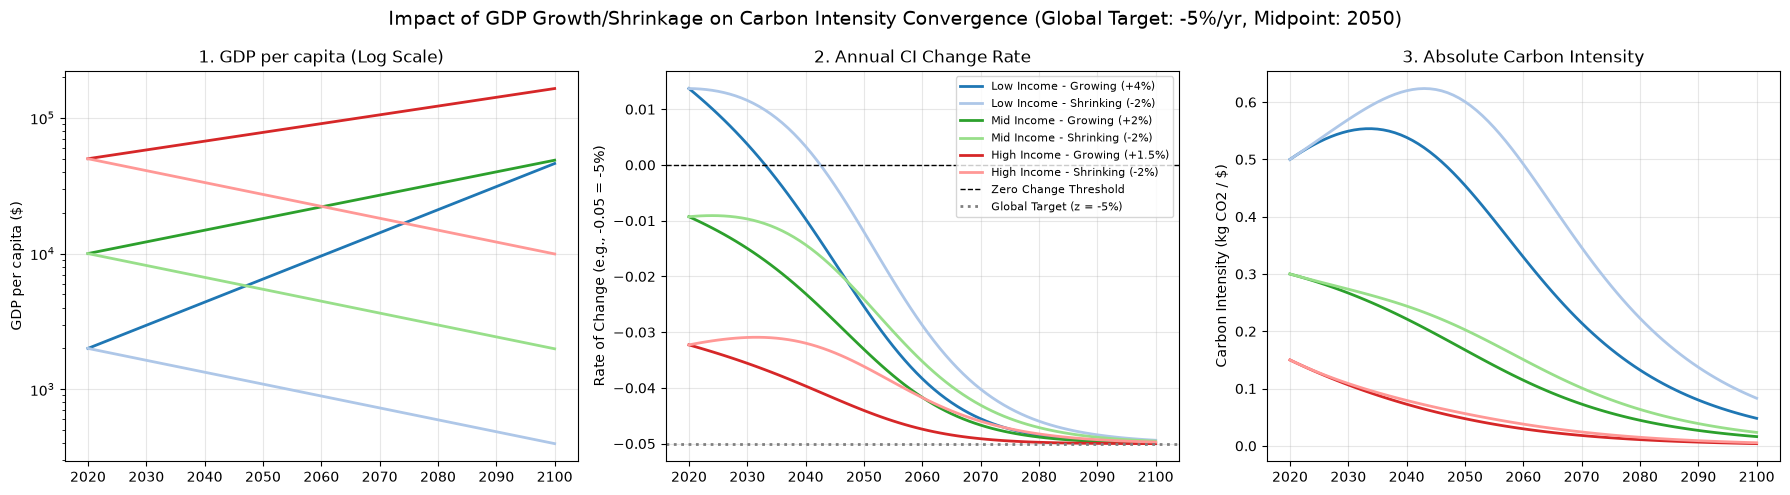

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. Define the Core Mathematical Functions
# ==========================================

def calc_modelled_trend(gdp_pc):
    """Calculates the income-dependent natural rate of carbon intensity change."""
    return -0.015 * np.log(gdp_pc) + 0.1309

def weighted_average(year, modelled_trend, z, k, t0):
    """
    Blends the country's natural trend with the global target (z) 
    using a sigmoidal S-curve based on time.
    """
    # Sigmoid function: approaches 0 early on, approaches 1 later on
    weight = 1 / (1 + np.exp(-k * (year - t0)))
    
    # Blend the two rates
    return modelled_trend * (1 - weight) + z * weight

def run_simulation(name, start_gdp_pc, gdp_growth_rate, start_ci, z=-0.05, k=0.1, t0=2050):
    """Simulates a country's trajectory from 2020 to 2100."""
    years = np.arange(2020, 2101)
    
    gdp_pc = start_gdp_pc
    ci = start_ci
    
    results = []
    
    for year in years:
        # 1. Calculate the natural trend based on current income
        trend = calc_modelled_trend(gdp_pc)
        
        # 2. Apply the time-based convergence weight
        actual_change_rate = weighted_average(year, trend, z, k, t0)
        
        # Record the year's data before updating
        results.append({
            'Year': year,
            'Scenario': name,
            'GDP_pc': gdp_pc,
            'Natural_Trend': trend,
            'Actual_CI_Change_Rate': actual_change_rate,
            'Carbon_Intensity': ci
        })
        
        # 3. Update the variables for the next year
        ci = ci * (1 + actual_change_rate)
        gdp_pc = gdp_pc * (1 + gdp_growth_rate) # Grow or shrink GDP
        
    return pd.DataFrame(results)

# ==========================================
# 2. Define Scenarios (Growing vs Shrinking)
# ==========================================

scenarios = [
    # Low Income ($2,000) -> Plausible starting CI: 0.5 kg CO2/$
    {"name": "Low Income - Growing (+4%)", "start_gdp": 2000, "growth": 0.04, "start_ci": 0.5},
    {"name": "Low Income - Shrinking (-2%)", "start_gdp": 2000, "growth": -0.02, "start_ci": 0.5},
    
    # Middle Income ($10,000) -> Plausible starting CI: 0.3 kg CO2/$
    {"name": "Mid Income - Growing (+2%)", "start_gdp": 10000, "growth": 0.02, "start_ci": 0.3},
    {"name": "Mid Income - Shrinking (-2%)", "start_gdp": 10000, "growth": -0.02, "start_ci": 0.3},
    
    # High Income ($50,000) -> Plausible starting CI: 0.15 kg CO2/$
    {"name": "High Income - Growing (+1.5%)", "start_gdp": 50000, "growth": 0.015, "start_ci": 0.15},
    {"name": "High Income - Shrinking (-2%)", "start_gdp": 50000, "growth": -0.02, "start_ci": 0.15},
]

# Run simulations and combine into one DataFrame
all_results = pd.concat([
    run_simulation(s["name"], s["start_gdp"], s["growth"], s["start_ci"]) 
    for s in scenarios
])

# ==========================================
# 3. Plot the Results
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Impact of GDP Growth/Shrinkage on Carbon Intensity Convergence (Global Target: -5%/yr, Midpoint: 2050)", fontsize=14)

# Colors to pair the growing/shrinking scenarios
colors = ['#1f77b4', '#aec7e8', '#2ca02c', '#98df8a', '#d62728', '#ff9896']

# Plot 1: GDP per capita over time
ax = axes[0]
for i, scenario in enumerate(all_results['Scenario'].unique()):
    data = all_results[all_results['Scenario'] == scenario]
    ax.plot(data['Year'], data['GDP_pc'], label=scenario, color=colors[i], linewidth=2)
ax.set_yscale('log')
ax.set_title("1. GDP per capita (Log Scale)")
ax.set_ylabel("GDP per capita ($)")
ax.grid(True, alpha=0.3)

# Plot 2: Annual Rate of Change in Carbon Intensity
ax = axes[1]
for i, scenario in enumerate(all_results['Scenario'].unique()):
    data = all_results[all_results['Scenario'] == scenario]
    ax.plot(data['Year'], data['Actual_CI_Change_Rate'], label=scenario, color=colors[i], linewidth=2)
ax.axhline(0, color='black', linestyle='--', linewidth=1, label="Zero Change Threshold")
ax.axhline(-0.05, color='gray', linestyle=':', linewidth=2, label="Global Target (z = -5%)")
ax.set_title("2. Annual CI Change Rate")
ax.set_ylabel("Rate of Change (e.g., -0.05 = -5%)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='upper right')

# Plot 3: Absolute Carbon Intensity Trajectory
ax = axes[2]
for i, scenario in enumerate(all_results['Scenario'].unique()):
    data = all_results[all_results['Scenario'] == scenario]
    ax.plot(data['Year'], data['Carbon_Intensity'], label=scenario, color=colors[i], linewidth=2)
ax.set_title("3. Absolute Carbon Intensity")
ax.set_ylabel("Carbon Intensity (kg CO2 / $)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

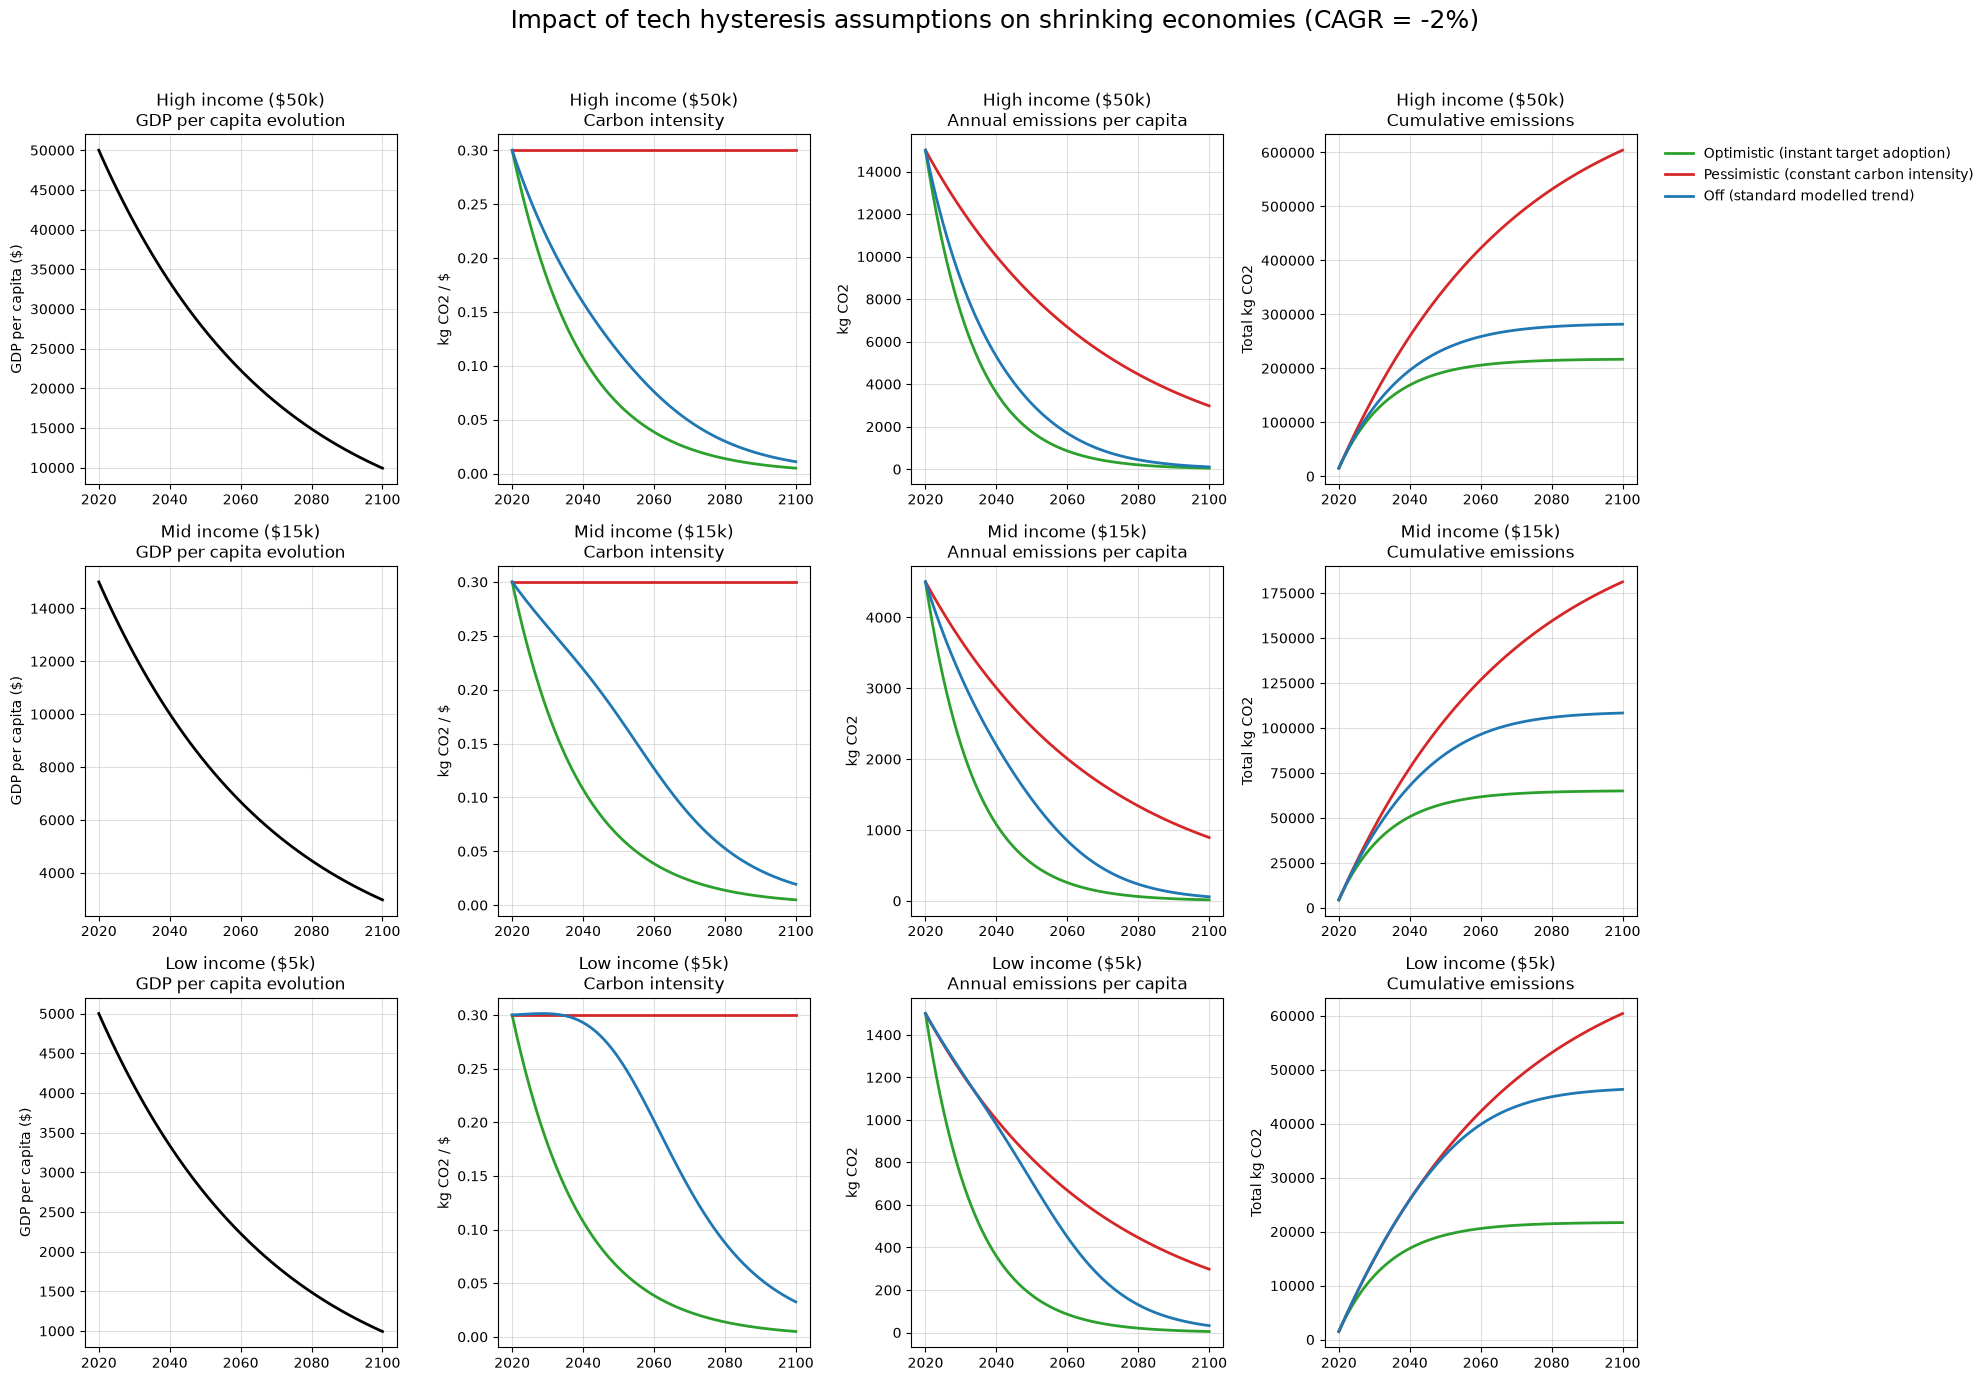

<Figure size 640x480 with 0 Axes>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. Define the core mathematical functions
# ==========================================

def calc_modelled_trend(gdp_pc):
    """Calculates the natural rate of carbon intensity change based on income."""
    return -0.015 * np.log(gdp_pc) + 0.1309

def weighted_average(year, modelled_trend, z, k, t0):
    """Sigmoidal transition from the modelled trend to the global target (z)."""
    weight = 1 / (1 + np.exp(-k * (year - t0)))
    return modelled_trend * (1 - weight) + z * weight

def run_degrowth_simulation(assumption, start_gdp_pc, start_ci, cagr=-0.02, z=-0.05, k=0.1, t0=2050):
    """Simulates a country from 2020 to 2100 under different tech change assumptions."""
    years = np.arange(2020, 2101)
    gdp_pc = start_gdp_pc
    ci = start_ci
    results = []
    
    for year in years:
        # Calculate emissions before updating (Emissions = GDP per capita * Carbon Intensity)
        emissions_pc = gdp_pc * ci
        
        results.append({
            'Year': year,
            'Assumption': assumption,
            'GDP_pc': gdp_pc,
            'Carbon_Intensity': ci,
            'Emissions_pc': emissions_pc
        })
        
        # Apply the hysteresis logic for degrowth (cagr <= 0)
        if assumption == "optimistic_degrowth":
            rate = z  # Instantly adopt the global target rate
        elif assumption == "pessimistic_degrowth":
            rate = 0  # Zero technological progress (constant carbon intensity)
        elif assumption == "off":
            trend = calc_modelled_trend(gdp_pc)
            rate = weighted_average(year, trend, z, k, t0) # Standard math
            
        # Evolve the variables for the next year
        ci = ci * (1 + rate)
        gdp_pc = gdp_pc * (1 + cagr) # GDP evolves over time
        
    return pd.DataFrame(results)

# ==========================================
# 2. Define starting levels & run scenarios
# ==========================================

# Define different starting points to create multiple rows
# UPDATED: All countries now start at the same carbon intensity (0.30)
starting_levels = [
    {"label": "High income ($50k)", "gdp": 50000, "ci": 0.30},
    {"label": "Mid income ($15k)",  "gdp": 15000, "ci": 0.30},
    {"label": "Low income ($5k)",   "gdp": 5000,  "ci": 0.30}
]

assumptions = ["optimistic_degrowth", "pessimistic_degrowth", "off"]
colors = {'optimistic_degrowth': '#2ca02c', 'pessimistic_degrowth': '#d62728', 'off': '#1f77b4'}
legend_labels = {
    'optimistic_degrowth': 'Optimistic (instant target adoption)', 
    'pessimistic_degrowth': 'Pessimistic (constant carbon intensity)', 
    'off': 'Off (standard modelled trend)'
}

# Run all simulations into a nested dictionary for easy plotting
all_results = {}
for level in starting_levels:
    lvl_label = level["label"]
    all_results[lvl_label] = pd.concat([
        run_degrowth_simulation(asm, level["gdp"], level["ci"]) 
        for asm in assumptions
    ])

# ==========================================
# 3. Plot the multi-row dashboard
# ==========================================

n_rows = len(starting_levels)
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4.5 * n_rows))
fig.suptitle("Impact of tech hysteresis assumptions on shrinking economies (CAGR = -2%)", fontsize=18, y=1.02)

for row_idx, level in enumerate(starting_levels):
    lvl_label = level["label"]
    data = all_results[lvl_label]
    
    # Column 1: GDP Evolution (Proving it shrinks)
    ax_gdp = axes[row_idx, 0]
    sample_data = data[data['Assumption'] == 'off'] 
    ax_gdp.plot(sample_data['Year'], sample_data['GDP_pc'], color='black', lw=2)
    ax_gdp.set_title(f"{lvl_label}\nGDP per capita evolution")
    ax_gdp.set_ylabel("GDP per capita ($)")
    ax_gdp.grid(alpha=0.4)
    
    # Column 2: Carbon Intensity
    ax_ci = axes[row_idx, 1]
    for asm in assumptions:
        subset = data[data['Assumption'] == asm]
        ax_ci.plot(subset['Year'], subset['Carbon_Intensity'], label=legend_labels[asm], color=colors[asm], lw=2)
    ax_ci.set_title(f"{lvl_label}\nCarbon intensity")
    ax_ci.set_ylabel("kg CO2 / $")
    ax_ci.grid(alpha=0.4)
    
    # Column 3: Annual Emissions Per Capita
    ax_em = axes[row_idx, 2]
    for asm in assumptions:
        subset = data[data['Assumption'] == asm]
        ax_em.plot(subset['Year'], subset['Emissions_pc'], label=legend_labels[asm], color=colors[asm], lw=2)
    ax_em.set_title(f"{lvl_label}\nAnnual emissions per capita")
    ax_em.set_ylabel("kg CO2")
    ax_em.grid(alpha=0.4)
    
    # Column 4: Cumulative Emissions
    ax_cum = axes[row_idx, 3]
    for asm in assumptions:
        subset = data[data['Assumption'] == asm]
        ax_cum.plot(subset['Year'], subset['Emissions_pc'].cumsum(), label=legend_labels[asm], color=colors[asm], lw=2)
    ax_cum.set_title(f"{lvl_label}\nCumulative emissions")
    ax_cum.set_ylabel("Total kg CO2")
    ax_cum.grid(alpha=0.4)
    
    # Add legend only to the top right chart to save space
    if row_idx == 0:
        ax_cum.legend(loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

plt.tight_layout()
plt.show()

#  save figure as supplementary figure on tech hysteresis assumptions
plt.savefig("supplementary_figure_8.png", dpi=300, bbox_inches='tight')

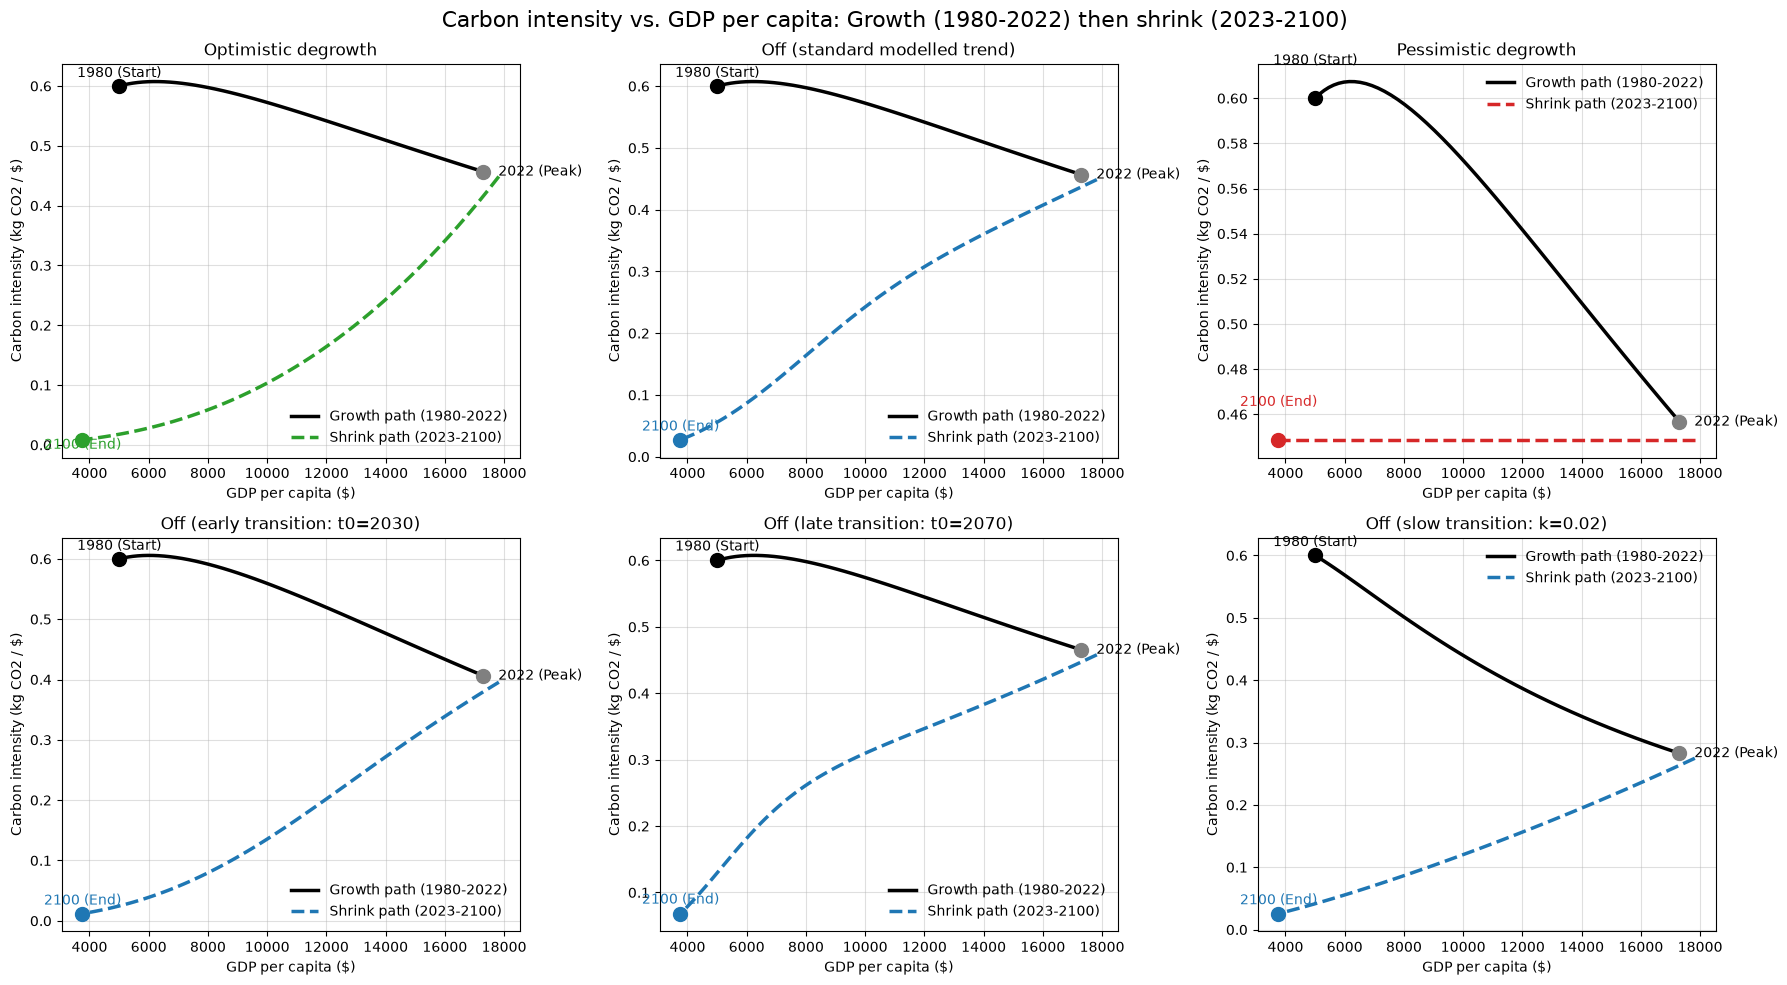

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. Core mathematical functions
# ==========================================

def calc_modelled_trend(gdp_pc):
    """Calculates the natural rate of carbon intensity change based on income."""
    return -0.015 * np.log(gdp_pc) + 0.1309

def weighted_average(year, modelled_trend, z, k, t0):
    """Sigmoidal transition from the modelled trend to the global target (z)."""
    weight = 1 / (1 + np.exp(-k * (year - t0)))
    return modelled_trend * (1 - weight) + z * weight

def run_boom_bust_simulation(assumption, start_gdp_pc=5000, start_ci=0.60, growth_rate=0.03, shrink_rate=-0.02, z=-0.05, k=0.1, t0=2050):
    """Simulates a country that grows from 1980 to 2022, then shrinks to 2100."""
    years = np.arange(1980, 2101)
    gdp_pc = start_gdp_pc
    ci = start_ci
    results = []
    
    for year in years:
        # Determine the current growth phase
        current_cagr = growth_rate if year <= 2022 else shrink_rate
        phase = "Growth (1980-2022)" if year <= 2022 else "Shrink (2023-2100)"
        
        results.append({
            'Year': year,
            'Phase': phase,
            'Assumption': assumption,
            'GDP_pc': gdp_pc,
            'Carbon_Intensity': ci
        })
        
        # Apply the hysteresis logic based on the CURRENT trajectory
        if assumption == "optimistic_degrowth" and current_cagr <= 0:
            rate = z  
        elif assumption == "pessimistic_degrowth" and current_cagr <= 0:
            rate = 0  
        else: # "off" assumption, or if the economy is currently growing
            trend = calc_modelled_trend(gdp_pc)
            rate = weighted_average(year, trend, z, k, t0)
            
        # Evolve the variables for the next year
        ci = ci * (1 + rate)
        gdp_pc = gdp_pc * (1 + current_cagr)
        
    return pd.DataFrame(results)

# ==========================================
# 2. Run scenarios
# ==========================================

# Define a grid of configurations to run
configs = [
    # Row 1: Core assumptions (Swapping Panel 2 and 3)
    {'asm': 'optimistic_degrowth', 'k': 0.1, 't0': 2050, 'title': 'Optimistic degrowth'},
    {'asm': 'off', 'k': 0.1, 't0': 2050, 'title': 'Off (standard modelled trend)'},
    {'asm': 'pessimistic_degrowth', 'k': 0.1, 't0': 2050, 'title': 'Pessimistic degrowth'},
    
    # Row 2: Testing the influence of S-curve parameters (t0 and k) on the "off" assumption
    {'asm': 'off', 'k': 0.1, 't0': 2030, 'title': 'Off (early transition: t0=2030)'},
    {'asm': 'off', 'k': 0.1, 't0': 2070, 'title': 'Off (late transition: t0=2070)'},
    {'asm': 'off', 'k': 0.02, 't0': 2050, 'title': 'Off (slow transition: k=0.02)'}
]

colors = {'optimistic_degrowth': '#2ca02c', 'pessimistic_degrowth': '#d62728', 'off': '#1f77b4'}

# We start at a low income in 1980 so it can grow substantially by 2022
all_data = []
for c in configs:
    df = run_boom_bust_simulation(c['asm'], k=c['k'], t0=c['t0'])
    all_data.append(df)

# ==========================================
# 3. Plot the phase portraits (CI vs GDP)
# ==========================================

# Increase the figure size to accommodate two rows
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Carbon intensity vs. GDP per capita: Growth (1980-2022) then shrink (2023-2100)", fontsize=16)

for i, c in enumerate(configs):
    # Calculate row and column index
    row_idx = i // 3
    col_idx = i % 3
    ax = axes[row_idx, col_idx]
    
    data = all_data[i]
    asm = c['asm']
    
    # Split data into growth and shrink phases
    growth_data = data[data['Phase'] == 'Growth (1980-2022)']
    shrink_data = data[data['Phase'] == 'Shrink (2023-2100)']
    
    # Plot the outward path (Growing)
    ax.plot(growth_data['GDP_pc'], growth_data['Carbon_Intensity'], 
            label='Growth path (1980-2022)', color='black', lw=2.5)
    
    # Plot the return path (Shrinking)
    ax.plot(shrink_data['GDP_pc'], shrink_data['Carbon_Intensity'], 
            label='Shrink path (2023-2100)', color=colors[asm], lw=2.5, linestyle='--')
    
    # Annotate the start, peak, and end points
    start_pt = data.iloc[0]
    peak_pt = data[data['Year'] == 2022].iloc[0]
    end_pt = data.iloc[-1]
    
    ax.scatter(start_pt['GDP_pc'], start_pt['Carbon_Intensity'], color='black', s=100, zorder=5)
    ax.text(start_pt['GDP_pc'], start_pt['Carbon_Intensity'] + 0.015, '1980 (Start)', ha='center')
    
    ax.scatter(peak_pt['GDP_pc'], peak_pt['Carbon_Intensity'], color='gray', s=100, zorder=5)
    ax.text(peak_pt['GDP_pc'] + 500, peak_pt['Carbon_Intensity'], '2022 (Peak)', va='center')
    
    ax.scatter(end_pt['GDP_pc'], end_pt['Carbon_Intensity'], color=colors[asm], s=100, zorder=5)
    
    # Adjust end point text position slightly based on the assumption so it doesn't overlap lines
    y_offset = -0.015 if asm == 'optimistic_degrowth' else 0.015
    ax.text(end_pt['GDP_pc'], end_pt['Carbon_Intensity'] + y_offset, '2100 (End)', ha='center', color=colors[asm])
    
    ax.set_title(c['title'])
    ax.set_xlabel("GDP per capita ($)")
    ax.set_ylabel("Carbon intensity (kg CO2 / $)")
    ax.grid(alpha=0.4)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()